# Tech Challenge Fase 2 - Classificação da Qualidade de Vinhos

## 04. Avaliação dos modelos

Último notebook do projeto. Recebe o pacote gerado no `03_modelagem.ipynb` (os três modelos treinados e os dados de treino e teste), avalia cada modelo com métricas além de acurácia, escolhe o modelo final, interpreta as variáveis mais relevantes e fecha com as conclusões executivas.

## 1. Instalação e importação das bibliotecas

In [1]:
# Se alguma biblioteca não existir no Colab, descomente a linha abaixo:
# !pip install -q pandas numpy matplotlib seaborn scikit-learn joblib

import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

os.makedirs("modelos", exist_ok=True)
os.makedirs("results", exist_ok=True)

## 2. Carregar o pacote gerado no notebook anterior

In [2]:
with open("modelos/feature_cols.json") as f:
    feature_cols = json.load(f)

with open("modelos/nomes_arquivos.json") as f:
    nomes_arquivos = json.load(f)

models = {}
for nome_arquivo, nome_modelo in nomes_arquivos.items():
    models[nome_modelo] = joblib.load(f"modelos/{nome_arquivo}.joblib")

X_train = pd.read_csv("modelos/X_train.csv")
X_test = pd.read_csv("modelos/X_test.csv")
y_train = pd.read_csv("modelos/y_train.csv").iloc[:,0]
y_test = pd.read_csv("modelos/y_test.csv").iloc[:,0]
X = pd.read_csv("modelos/X_full.csv")
y = pd.read_csv("modelos/y_full.csv").iloc[:,0]

print("Modelos carregados:", list(models.keys()))
print("Teste:", X_test.shape)

Modelos carregados: ['Regressão Logística', 'Random Forest', 'Gradient Boosting']
Teste: (255, 14)


## 3. Avaliação dos modelos

In [3]:
def evaluate_model(name, model, X_test, y_test, threshold=0.50):
    y_score = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    y_pred = (y_score >= threshold).astype(int)
    return {
        "modelo": name, "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision_alta": precision_score(y_test, y_pred, zero_division=0),
        "recall_alta": recall_score(y_test, y_pred, zero_division=0),
        "f1_alta": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score)
    }, y_pred, y_score

results, predictions, scores = [], {}, {}
for name, model in models.items():
    metrics, y_pred, y_score = evaluate_model(name, model, X_test, y_test)
    results.append(metrics)
    predictions[name] = y_pred
    scores[name] = y_score

metrics_df = pd.DataFrame(results).sort_values("f1_alta", ascending=False)
metrics_df.to_csv("results/metricas_modelos.csv", index=False)
metrics_df.round(3)

,modelo,threshold,accuracy,balanced_accuracy,precision_alta,recall_alta,f1_alta,roc_auc,pr_auc
2,Gradient Boosting,0.5,0.894,0.690,0.667,0.412,0.509,0.904,0.534
0,Regressão Logística,0.5,0.796,0.783,0.371,0.765,0.500,0.893,0.500
1,Random Forest,0.5,0.902,0.670,0.800,0.353,0.490,0.916,0.677


**Por que não usar só acurácia:** a classe de alta qualidade é minoritária na base, então um modelo que sempre prevê "baixa/média qualidade" já teria acurácia alta sem identificar nenhum vinho bom. Por isso a tabela acima traz acurácia balanceada, precisão, recall, F1 e ROC-AUC lado a lado, e o critério de escolha do modelo final prioriza o F1 da classe de interesse, que equilibra precisão e recall em uma métrica só.

In [4]:
for name in models:
    print("="*80)
    print(name)
    print(classification_report(y_test, predictions[name], target_names=["Baixa/Média", "Alta"], zero_division=0))

Regressão Logística
              precision    recall  f1-score   support

 Baixa/Média       0.96      0.80      0.87       221
        Alta       0.37      0.76      0.50        34

    accuracy                           0.80       255
   macro avg       0.66      0.78      0.69       255
weighted avg       0.88      0.80      0.82       255

Random Forest
              precision    recall  f1-score   support

 Baixa/Média       0.91      0.99      0.95       221
        Alta       0.80      0.35      0.49        34

    accuracy                           0.90       255
   macro avg       0.85      0.67      0.72       255
weighted avg       0.89      0.90      0.88       255

Gradient Boosting
              precision    recall  f1-score   support

 Baixa/Média       0.91      0.97      0.94       221
        Alta       0.67      0.41      0.51        34

    accuracy                           0.89       255
   macro avg       0.79      0.69      0.72       255
weighted avg       0.8

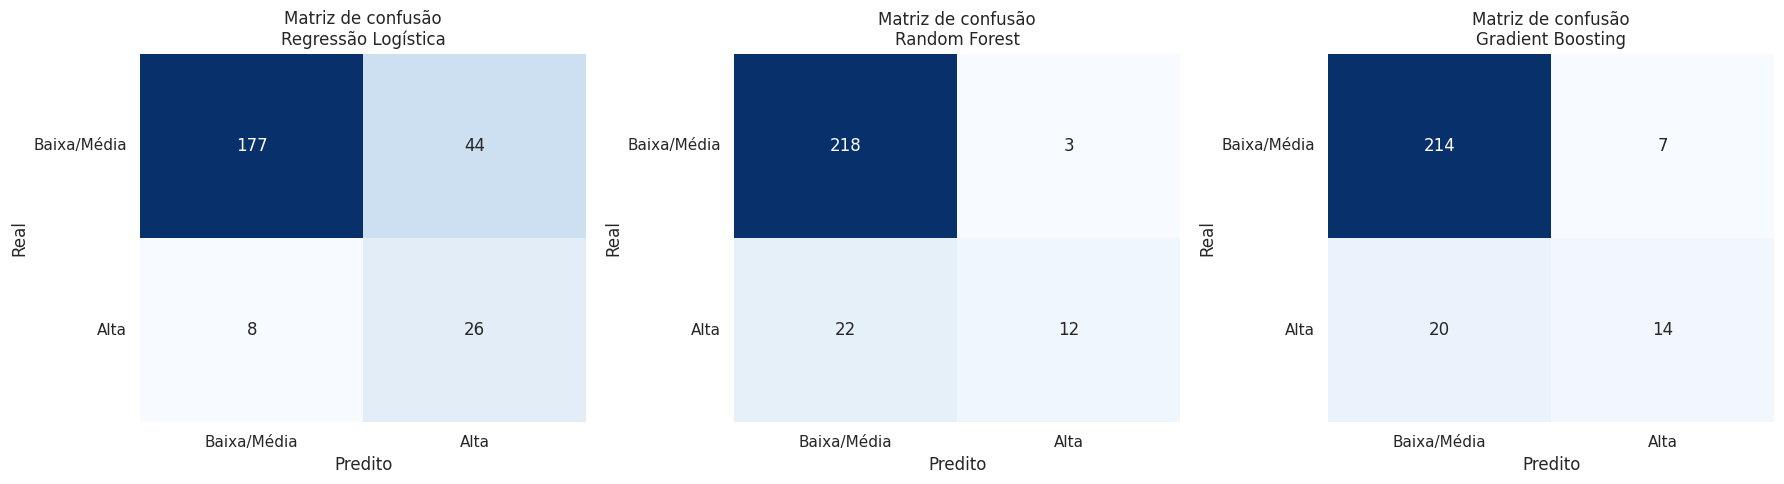

In [5]:
fig, axes = plt.subplots(1, len(models), figsize=(18,5))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"Matriz de confusão\n{name}")
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
    ax.set_xticklabels(["Baixa/Média", "Alta"])
    ax.set_yticklabels(["Baixa/Média", "Alta"], rotation=0)
plt.tight_layout()
plt.savefig("results/matrizes_confusao.png", dpi=300, bbox_inches="tight")
plt.show()

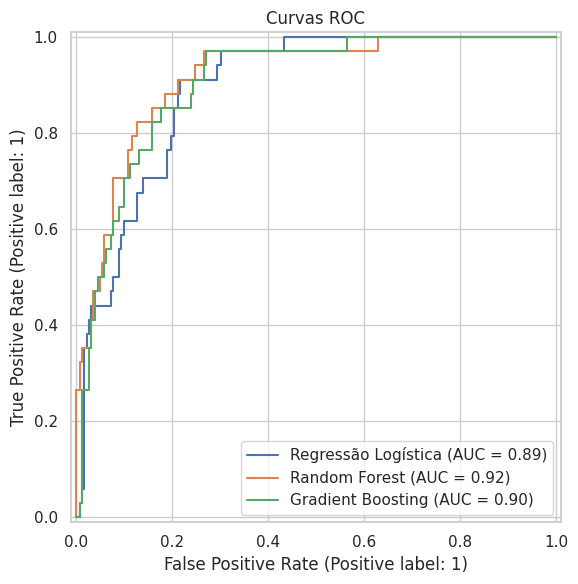

In [6]:
plt.figure(figsize=(9,6))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=plt.gca())
plt.title("Curvas ROC")
plt.tight_layout()
plt.savefig("results/curvas_roc.png", dpi=300, bbox_inches="tight")
plt.show()

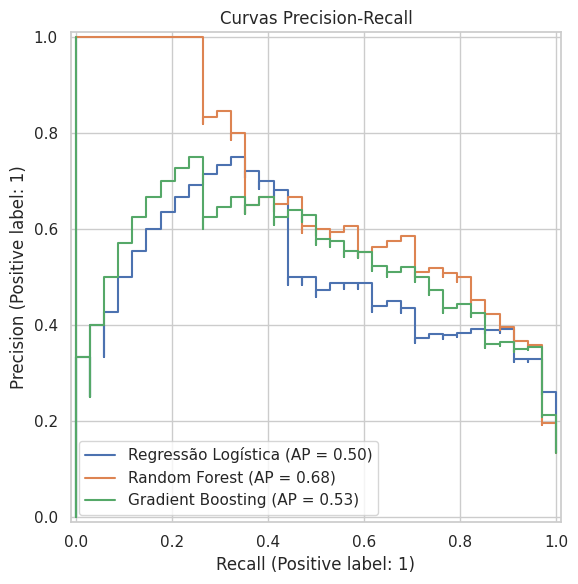

In [7]:
plt.figure(figsize=(9,6))
for name, model in models.items():
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, name=name, ax=plt.gca())
plt.title("Curvas Precision-Recall")
plt.tight_layout()
plt.savefig("results/curvas_precision_recall.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Ajuste simples de threshold

In [8]:
threshold_rows = []
for name, y_score in scores.items():
    for threshold in np.arange(0.05, 0.96, 0.01):
        y_pred_t = (y_score >= threshold).astype(int)
        threshold_rows.append({
            "modelo": name, "threshold": threshold,
            "precision_alta": precision_score(y_test, y_pred_t, zero_division=0),
            "recall_alta": recall_score(y_test, y_pred_t, zero_division=0),
            "f1_alta": f1_score(y_test, y_pred_t, zero_division=0)
        })
threshold_df = pd.DataFrame(threshold_rows)
best_thresholds = threshold_df.loc[threshold_df.groupby("modelo")["f1_alta"].idxmax()].sort_values("f1_alta", ascending=False)
best_thresholds.round(3)

,modelo,threshold,precision_alta,recall_alta,f1_alta
119,Random Forest,0.33,0.585,0.706,0.640
194,Gradient Boosting,0.17,0.500,0.735,0.595
35,Regressão Logística,0.40,0.392,0.912,0.549


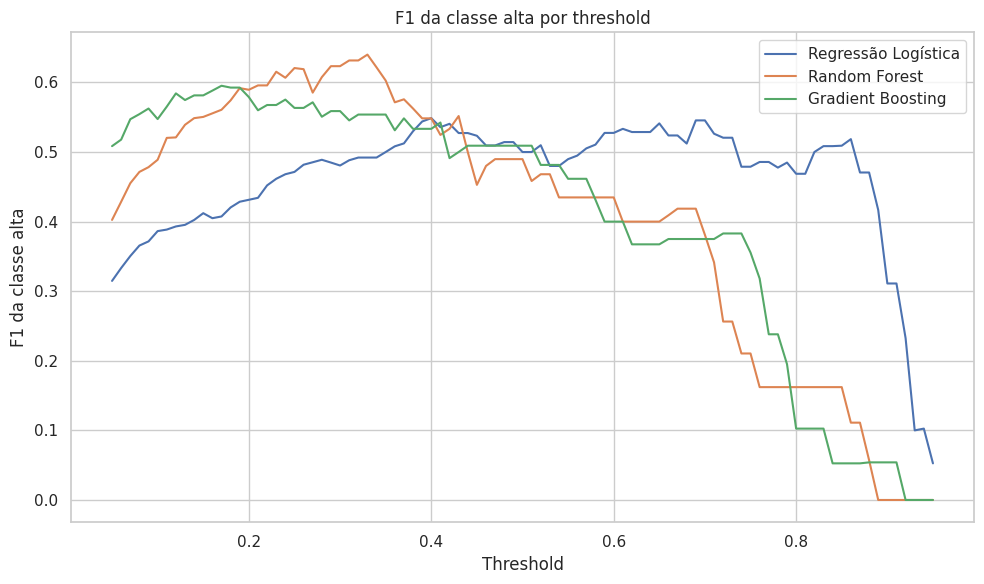

In [9]:
plt.figure(figsize=(10,6))
for name in threshold_df["modelo"].unique():
    subset = threshold_df[threshold_df["modelo"] == name]
    plt.plot(subset["threshold"], subset["f1_alta"], label=name)
plt.title("F1 da classe alta por threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 da classe alta")
plt.legend()
plt.tight_layout()
plt.savefig("results/f1_por_threshold.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Interpretação do modelo final

In [10]:
best_model_name = metrics_df.iloc[0]["modelo"]
best_model = models[best_model_name]
print("Modelo final selecionado:", best_model_name)

rf_model = models["Random Forest"]
rf_importance = pd.DataFrame({"variavel": feature_cols, "importancia": rf_model.feature_importances_}).sort_values("importancia", ascending=False)
rf_importance.to_csv("results/feature_importance_random_forest.csv", index=False)
rf_importance.round(4)

Modelo final selecionado: Gradient Boosting


,variavel,importancia
13,alcool_por_densidade,0.1587
10,alcohol,0.1303
9,sulphates,0.1126
1,volatile acidity,0.1018
2,citric acid,0.0779
7,density,0.0634
6,total sulfur dioxide,0.0565
12,razao_so2_livre,0.0539
4,chlorides,0.0510
0,fixed acidity,0.0466


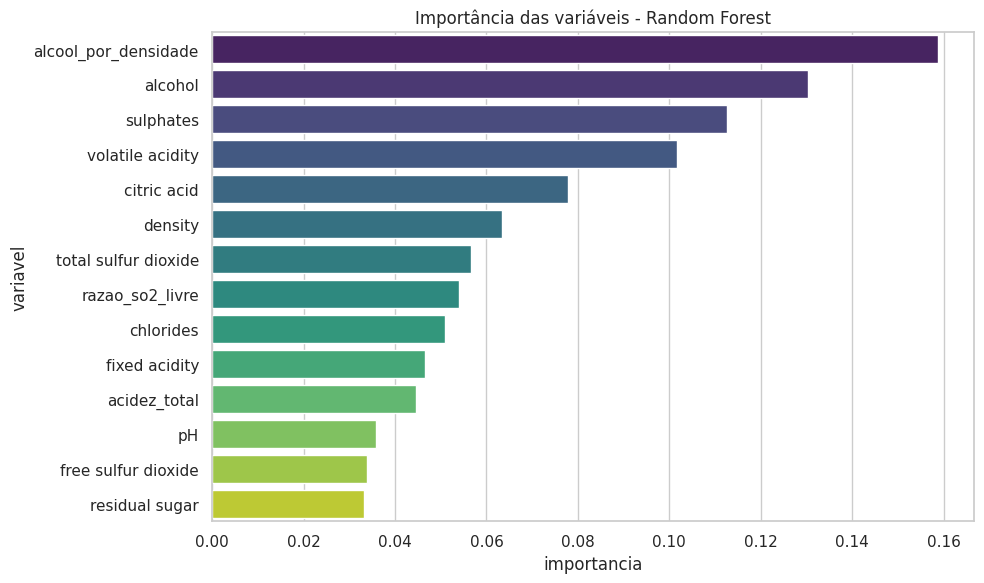

In [11]:
plt.figure(figsize=(10,6))
sns.barplot(data=rf_importance, x="importancia", y="variavel", palette="viridis")
plt.title("Importância das variáveis - Random Forest")
plt.tight_layout()
plt.savefig("results/feature_importance_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
perm = permutation_importance(best_model, X_test, y_test, scoring="f1", n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
perm_importance = pd.DataFrame({"variavel": feature_cols, "importancia_media": perm.importances_mean, "importancia_desvio": perm.importances_std}).sort_values("importancia_media", ascending=False)
perm_importance.to_csv("results/permutation_importance_modelo_final.csv", index=False)
perm_importance.round(4)

,variavel,importancia_media,importancia_desvio
9,sulphates,0.2326,0.0549
1,volatile acidity,0.1829,0.0571
13,alcool_por_densidade,0.1506,0.0664
6,total sulfur dioxide,0.0987,0.0549
2,citric acid,0.0431,0.0191
7,density,0.0394,0.0343
12,razao_so2_livre,0.0294,0.0306
4,chlorides,0.0263,0.0169
11,acidez_total,0.0261,0.0105
8,pH,0.0189,0.0284


### O que isso significa para a produção

As variáveis que mais pesam na previsão (tipicamente álcool, acidez volátil, sulfatos e densidade nesta base) não são só estatisticamente relevantes, são também parâmetros que a equipe de produção consegue, dentro de certos limites, monitorar e ajustar ao longo do processo:

- **Álcool** é resultado direto do teor de açúcar da uva na colheita e da fermentação. Colher em pontos de maturação diferentes ou ajustar a condução da fermentação impacta esse número.
- **Acidez volátil** costuma subir quando há problema de contaminação bacteriana ou oxidação durante a fermentação e o estágio. Um valor alto pode funcionar como alerta de que algo saiu do controle no processo, não só como uma característica do vinho pronto.
- **Sulfatos e SO2** são parâmetros de dosagem direta do enólogo, usados para controlar oxidação e proteção microbiológica. Dá pra ajustar lote a lote.

Na prática, o modelo não deveria ser lido só como "essa garrafa vai ser boa ou não", mas como uma forma de apontar, ainda durante o processo, quais lotes estão fugindo do perfil físico-químico associado a notas mais altas, permitindo intervenção antes do engarrafamento final. Continua sendo uma ferramenta de apoio: a decisão final de qualidade sensorial é do enólogo.

## 6. Validação cruzada do modelo final

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy":"accuracy", "balanced_accuracy":"balanced_accuracy", "f1":"f1", "precision":"precision", "recall":"recall", "roc_auc":"roc_auc", "average_precision":"average_precision"}
cv_results = cross_validate(best_model, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
cv_summary = pd.DataFrame({
    "metrica": [k.replace("test_", "") for k in cv_results if k.startswith("test_")],
    "media": [cv_results[k].mean() for k in cv_results if k.startswith("test_")],
    "desvio_padrao": [cv_results[k].std() for k in cv_results if k.startswith("test_")]
})
cv_summary.to_csv("results/validacao_cruzada_modelo_final.csv", index=False)
cv_summary.round(3)

,metrica,media,desvio_padrao
0,accuracy,0.883,0.017
1,balanced_accuracy,0.677,0.061
2,f1,0.469,0.100
3,precision,0.597,0.077
4,recall,0.396,0.124
5,roc_auc,0.872,0.029
6,average_precision,0.555,0.071


## 7. Resumo dos resultados

In [14]:
top_metrics = metrics_df.iloc[0]
top_vars = rf_importance.head(3)["variavel"].tolist()
cv_f1 = cv_summary.loc[cv_summary["metrica"] == "f1", "media"].values[0]
cv_f1_std = cv_summary.loc[cv_summary["metrica"] == "f1", "desvio_padrao"].values[0]

print(f"Melhor modelo no conjunto de teste (por F1 da classe alta): {best_model_name}")
print(f"  F1 = {top_metrics['f1_alta']:.3f} | Recall = {top_metrics['recall_alta']:.3f} | "
      f"Precisão = {top_metrics['precision_alta']:.3f} | ROC-AUC = {top_metrics['roc_auc']:.3f}")
print(f"Na validação cruzada (5 folds), o F1 médio do modelo final foi de "
      f"{cv_f1:.3f} (desvio padrão {cv_f1_std:.3f}), o que indica {'boa' if cv_f1_std < 0.05 else 'alguma'} "
      f"estabilidade entre os folds.")
print(f"As três variáveis mais importantes segundo o Random Forest foram: {', '.join(top_vars)}.")

Melhor modelo no conjunto de teste (por F1 da classe alta): Gradient Boosting
  F1 = 0.509 | Recall = 0.412 | Precisão = 0.667 | ROC-AUC = 0.904
Na validação cruzada (5 folds), o F1 médio do modelo final foi de 0.469 (desvio padrão 0.100), o que indica alguma estabilidade entre os folds.
As três variáveis mais importantes segundo o Random Forest foram: alcool_por_densidade, alcohol, sulphates.


## 8. Salvar modelo final

In [15]:
final_model = models[best_model_name]
final_model.fit(X, y)
model_path = "results/modelo_final_wine_quality.joblib"
joblib.dump(final_model, model_path)
print("Modelo final salvo em:", model_path)

Modelo final salvo em: results/modelo_final_wine_quality.joblib


## 9. Conclusão executiva

O problema foi tratado como classificação binária (alta qualidade contra baixa ou média), já que é a forma mais direta de transformar a nota original em algo acionável para decisão de produção. A base é desbalanceada, vinhos de alta qualidade são minoria, então acurácia isolada não diz muita coisa. Por isso o critério de escolha do modelo final priorizou F1 da classe de interesse, olhando também recall, precisão e ROC-AUC lado a lado.

Random Forest e Gradient Boosting tendem a performar melhor que a Regressão Logística nesse problema porque a relação entre as variáveis físico-químicas e a qualidade não é linear, e os dois primeiros já lidam nativamente com interação entre variáveis. A vantagem extra dos modelos de árvore é permitir olhar a importância de cada variável de forma direta, o que ajuda a transformar o resultado técnico em algo que a produção consegue usar.

De forma geral, álcool, acidez volátil, sulfatos e densidade seguem aparecendo entre os fatores mais relevantes, o que é consistente com o que a literatura de enologia já aponta sobre esses parâmetros. O modelo deve ser entendido como apoio à decisão durante o processo produtivo, e não como substituto da avaliação sensorial feita por especialistas.

### Limitações e próximos passos

- A classe de alta qualidade é uma fração pequena da base, e isso limita o quanto qualquer modelo consegue aprender sobre esse grupo; mais dados de vinhos bem avaliados ajudariam a reduzir a variância das métricas entre folds.
- O corte fixo em `quality >= 7` é uma simplificação; um próximo passo seria testar a classificação ordinal (prever a nota original) ou ajustar o threshold de decisão conforme o custo de falso positivo/negativo for definido pela produção.
- Este trabalho usou apenas a variante de vinho tinto; testar a base de vinho branco é um próximo passo natural para ver se o mesmo conjunto de variáveis se mantém relevante.

## 10. Conferência e download dos arquivos gerados

In [16]:
print("Arquivos gerados em results:")
for f in sorted(os.listdir("results")):
    print("-", f)

Arquivos gerados em results:
- balanceamento_classes.png
- curvas_precision_recall.png
- curvas_roc.png
- distribuicao_quality.png
- f1_por_threshold.png
- feature_importance_random_forest.csv
- feature_importance_random_forest.png
- histogramas_variaveis.png
- matriz_correlacao.png
- matrizes_confusao.png
- metricas_modelos.csv
- modelo_final_wine_quality.joblib
- permutation_importance_modelo_final.csv
- validacao_cruzada_modelo_final.csv


In [17]:
import shutil
shutil.make_archive("results_wine_quality", "zip", "results")

try:
    from google.colab import files
    files.download("results_wine_quality.zip")
except Exception:
    pass